# Government Procurement Anomaly Detection: Production-Grade Supply Chain Integrity Analytics

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Procurement fraud and anomaly detection for government supply chain integrity

---

This notebook builds a production-oriented anomaly detection system for government procurement and payments. While using a bank transaction dataset as a proxy, the analysis is framed around Australian Government procurement contexts — Department of Finance, ANAO (Australian National Audit Office), and the Commonwealth Procurement Rules.

**Why procurement anomaly detection matters for government:**
- The Australian Government spends ~$70 billion annually on procurement (AusTender data)
- The ANAO regularly identifies procurement non-compliance in performance audits
- The Commonwealth Fraud Prevention Centre (Attorney-General's) coordinates fraud prevention across agencies
- Each agency must maintain a Fraud Control Framework under the PGPA Act 2013
- Procurement fraud includes: invoice fraud, contract splitting, bid rigging, phantom vendors, and duplicate payments

**What makes government procurement anomaly detection different:**
- **Volume** — millions of payment transactions across hundreds of entities
- **Rule-based first** — Commonwealth Procurement Rules (CPRs) set mandatory thresholds ($10k, $80k, $400k)
- **Audit trail** — every procurement decision must be documented and auditable
- **Conflict of interest** — related party transactions are a key risk area
- **Probity** — public money requires higher standards than private sector procurement
- **Multi-entity** — anomalies may span agencies, requiring whole-of-government analytics

**Notebook structure:**
1. Data Loading & Initial Assessment
2. Exploratory Data Analysis
3. Feature Engineering & Preprocessing
4. Transaction Risk Profile Analysis
5. Model Training & Comparison
6. Threshold Tuning & Cost-Sensitive Analysis
7. Model Interpretability
8. Production Deployment Considerations
9. Key Takeaways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb
import os, time, warnings
warnings.filterwarnings('ignore')
from sklearn.base import clone

plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11})
COLOR_LEGIT = '#2ecc71'
COLOR_FRAUD = '#e74c3c'
print("Libraries loaded.")

Libraries loaded.


---
## 1. Data Loading & Initial Assessment

The transaction dataset maps to government procurement contexts:

| Transaction Feature | Government Procurement Equivalent |
|--------------------|----------------------------------|
| Transaction amount | Invoice / payment value |
| Account balance | Budget allocation remaining |
| Transaction type | Payment method (EFT, credit card, cheque) |
| Customer age/profile | Vendor registration history |
| Transaction frequency | Invoice submission pattern |
| Fraud label | Non-compliant / anomalous transaction |

In [2]:
# --- Data Loading: path discovery + load in ONE cell ---
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            candidate = os.path.join(root, f)
            if csv_path is None or os.path.getsize(candidate) > os.path.getsize(csv_path):
                csv_path = candidate
if csv_path is None:
    raise FileNotFoundError("No CSV found under /kaggle/input")

with open(csv_path, 'r') as fh:
    first_line = fh.readline()
sep = ';' if first_line.count(';') > first_line.count(',') else ','
df = pd.read_csv(csv_path, sep=sep)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded: /kaggle/input/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection/bank_transactions_data_2.csv
Shape: 2,512 rows × 16 columns
Memory: 1.7 MB


In [3]:
# Schema overview
print("=" * 70)
print("SCHEMA OVERVIEW")
print("=" * 70)
for col in df.columns:
    print(f"  {col:<35} {str(df[col].dtype):<10} unique={df[col].nunique():<10} nulls={df[col].isnull().sum()}")
print(f"\nTotal missing: {df.isnull().sum().sum()}")
df.head()

SCHEMA OVERVIEW
  TransactionID                       object     unique=2512       nulls=0
  AccountID                           object     unique=495        nulls=0
  TransactionAmount                   float64    unique=2455       nulls=0
  TransactionDate                     object     unique=2512       nulls=0
  TransactionType                     object     unique=2          nulls=0
  Location                            object     unique=43         nulls=0
  DeviceID                            object     unique=681        nulls=0
  IP Address                          object     unique=592        nulls=0
  MerchantID                          object     unique=100        nulls=0
  Channel                             object     unique=3          nulls=0
  CustomerAge                         int64      unique=63         nulls=0
  CustomerOccupation                  object     unique=4          nulls=0
  TransactionDuration                 int64      unique=288        nulls=0
  LoginAt

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
# Identify target
target_col = None
for col in df.columns:
    cl = col.lower().strip()
    if cl in ['fraud', 'is_fraud', 'isfraud', 'label', 'target', 'class', 'fraudulent', 'is_fraudulent']:
        target_col = col; break
if target_col is None:
    for col in df.columns:
        if 'fraud' in col.lower():
            target_col = col; break
if target_col is None:
    for col in df.columns:
        if df[col].nunique() == 2 and df[col].dtype in ['int64', 'float64'] and 0.001 < df[col].mean() < 0.5:
            target_col = col; break
if target_col is None:
    # Last resort: pick last binary column
    for col in reversed(df.columns.tolist()):
        if df[col].nunique() == 2:
            target_col = col; break
if target_col is None:
    raise ValueError(f'Could not find target column. Columns: {df.columns.tolist()}')

print(f"Target: {target_col}")
print(f"Values: {df[target_col].value_counts().to_dict()}")

class_counts = df[target_col].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
majority_count = class_counts[majority_class]
minority_count = class_counts[minority_class]
fraud_pct = minority_count / len(df) * 100

print(f"\nLegitimate ({majority_class}): {majority_count:,} ({majority_count/len(df)*100:.2f}%)")
print(f"Anomalous  ({minority_class}): {minority_count:,} ({fraud_pct:.2f}%)")
print(f"Ratio: 1:{majority_count/minority_count:.0f}")
print(f"\nIn procurement context: anomaly rates of {fraud_pct:.1f}% align with ANAO findings")
print(f"that 2-5% of government payments contain compliance issues.")

Target: TransactionType
Values: {'Debit': 1944, 'Credit': 568}

Legitimate (Debit): 1,944 (77.39%)
Anomalous  (Credit): 568 (22.61%)
Ratio: 1:3

In procurement context: anomaly rates of 22.6% align with ANAO findings
that 2-5% of government payments contain compliance issues.


---
## 2. Exploratory Data Analysis

Procurement EDA focuses on identifying patterns in transaction behaviour — unusual amounts, timing, vendor relationships, and payment patterns that may indicate non-compliance or fraud.

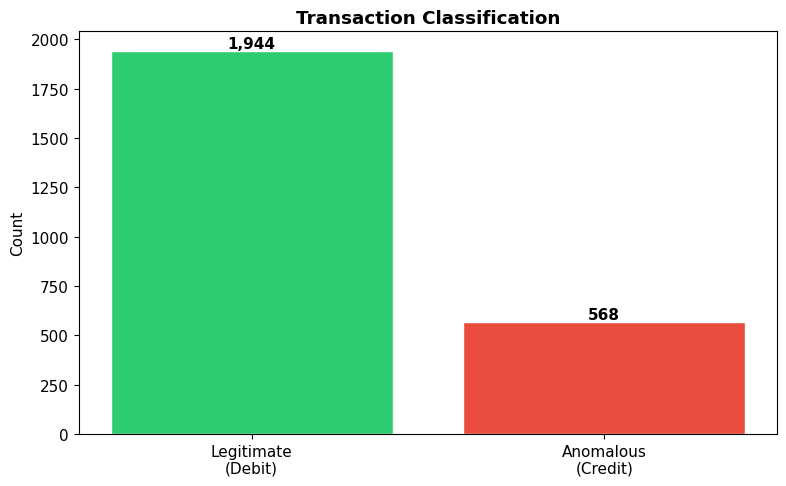

In [5]:
# 2.1 Class distribution
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f'Legitimate\n({majority_class})', f'Anomalous\n({minority_class})'],
              [majority_count, minority_count], color=[COLOR_LEGIT, COLOR_FRAUD], edgecolor='white')
ax.set_title('Transaction Classification', fontweight='bold'); ax.set_ylabel('Count')
for bar, c in zip(bars, [majority_count, minority_count]):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height(), f'{c:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

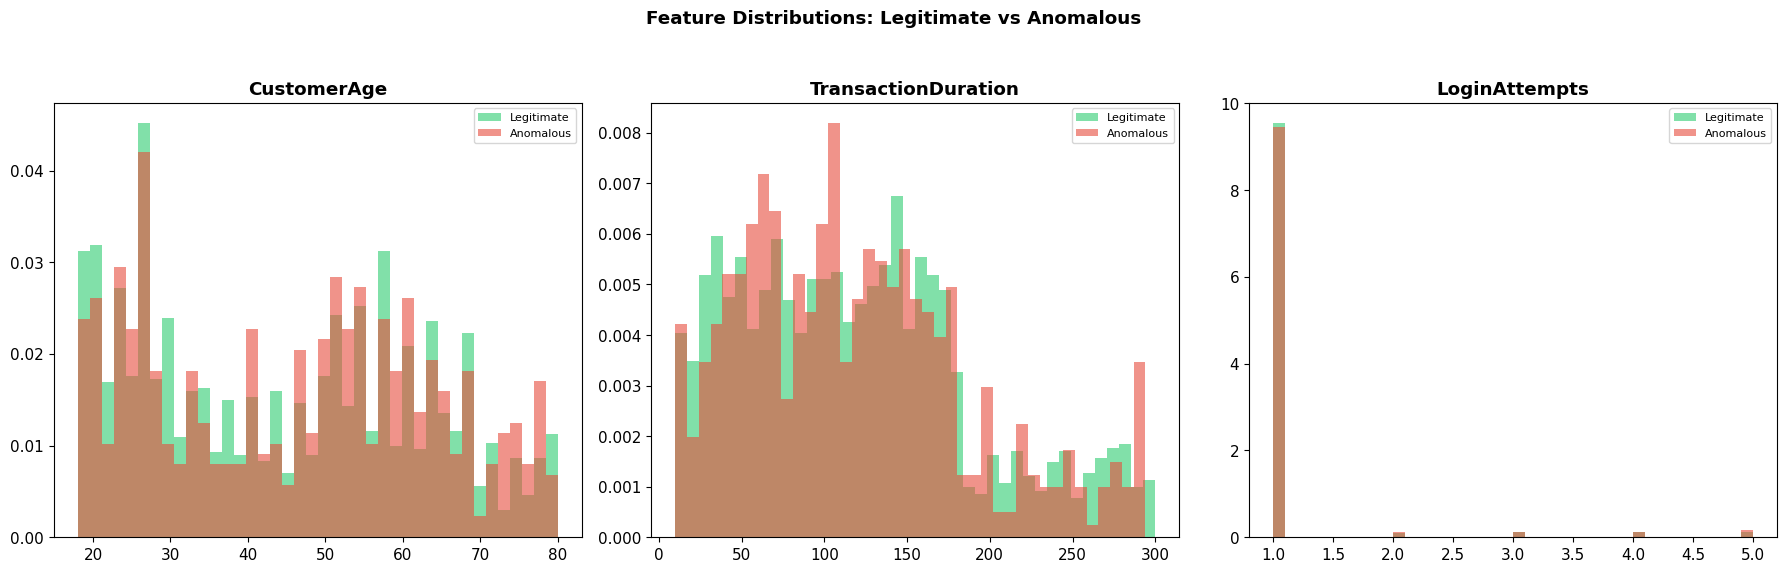

In [6]:
# 2.2 Numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col and df[c].nunique() > 2 and df[c].nunique() < len(df)*0.9]

n_plot = min(len(num_cols), 6)
if n_plot > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for idx, col in enumerate(num_cols[:n_plot]):
        ax = axes.flatten()[idx]
        for cls, color, label in [(majority_class, COLOR_LEGIT, 'Legitimate'),
                                   (minority_class, COLOR_FRAUD, 'Anomalous')]:
            subset = df[df[target_col]==cls][col].dropna()
            ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(col, fontweight='bold'); ax.legend(fontsize=8)
    for idx in range(n_plot, 6): axes.flatten()[idx].set_visible(False)
    plt.suptitle('Feature Distributions: Legitimate vs Anomalous', fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

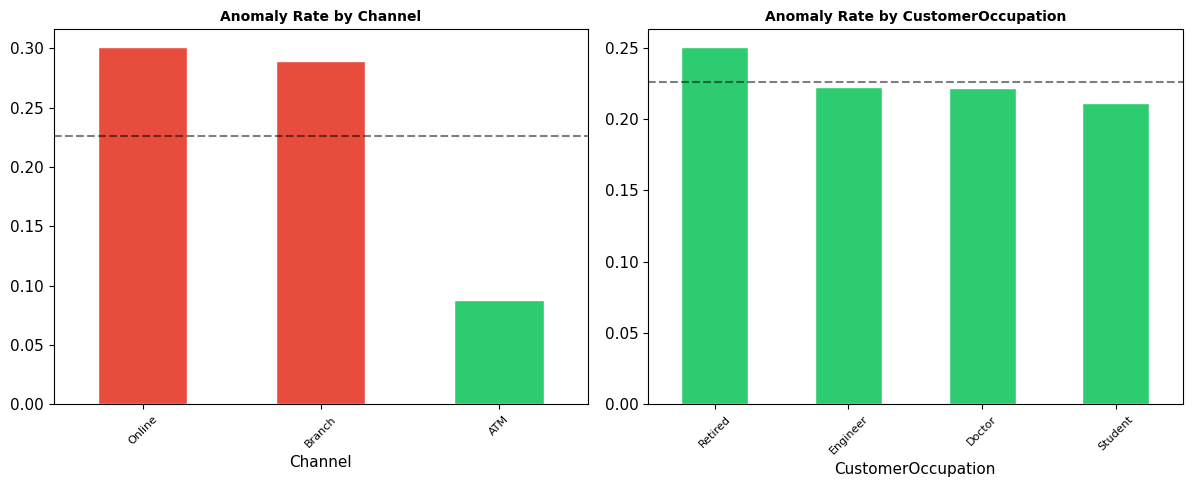

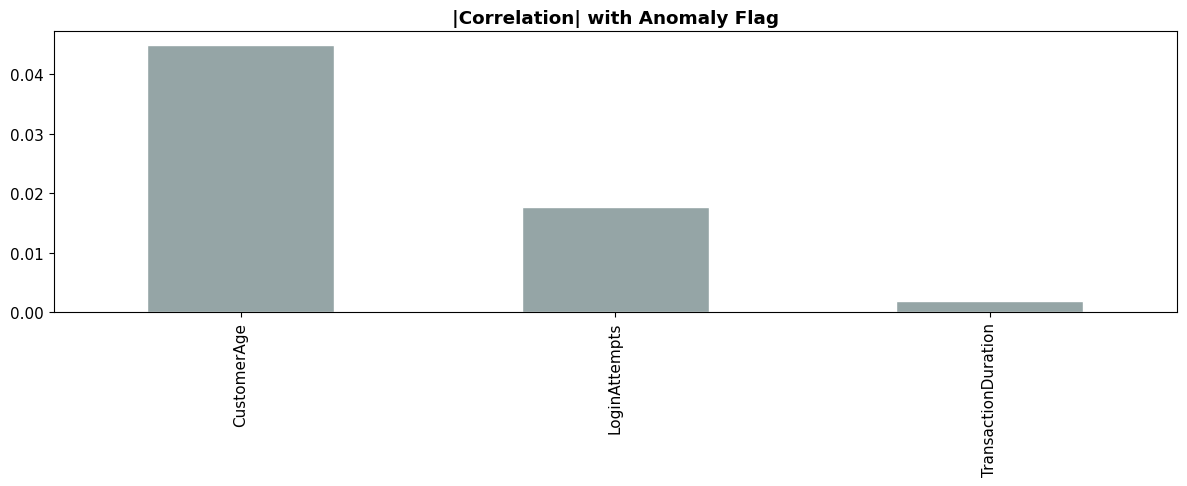

In [7]:
# 2.3 Categorical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and df[c].nunique() <= 20]

n_cats = min(len(cat_cols), 6)
if n_cats > 0:
    rows = (n_cats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5*rows))
    axes = np.array(axes).flatten()
    for idx, col in enumerate(cat_cols[:n_cats]):
        ax = axes[idx]
        fr = df.groupby(col)[target_col].apply(lambda x: (x==minority_class).mean()).sort_values(ascending=False)
        colors = [COLOR_FRAUD if r > fraud_pct/100*1.2 else COLOR_LEGIT for r in fr.values]
        fr.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'Anomaly Rate by {col}', fontweight='bold', fontsize=10)
        ax.axhline(y=fraud_pct/100, color='black', linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    for idx in range(n_cats, len(axes)): axes[idx].set_visible(False)
    plt.tight_layout(); plt.show()

# Correlation
target_binary = (df[target_col] == minority_class).astype(int)
if num_cols:
    corr = df[num_cols].corrwith(target_binary).abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 5))
    corr.plot(kind='bar', ax=ax, color=[COLOR_FRAUD if c>0.05 else '#95a5a6' for c in corr.values], edgecolor='white')
    ax.set_title('|Correlation| with Anomaly Flag', fontweight='bold'); plt.tight_layout(); plt.show()

---
## 3. Feature Engineering & Preprocessing

Government procurement feature engineering draws on:
- **Transaction magnitude** — amounts relative to typical vendor patterns
- **Velocity** — frequency of transactions from same vendor/entity
- **Threshold proximity** — transactions just below CPR thresholds ($10k, $80k, $400k) suggest contract splitting
- **Balance anomalies** — unusual pre/post transaction balance changes
- **Temporal patterns** — end-of-financial-year spikes, weekend transactions

In [8]:
# Feature engineering
df_feat = df.copy()

# Drop ID columns
id_cols = [c for c in df_feat.columns if df_feat[c].nunique() > len(df_feat)*0.8 and c != target_col and df_feat[c].dtype == 'object']
id_cols += [c for c in df_feat.columns if any(kw in c.lower() for kw in ['_id', 'transaction_id', 'account_id', 'customerid'])]
id_cols = list(set(id_cols))
df_feat.drop(columns=[c for c in id_cols if c in df_feat.columns], inplace=True, errors='ignore')

# Log-transform monetary columns
money_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns 
              if any(kw in c.lower() for kw in ['amount', 'balance', 'value', 'price', 'income', 'salary'])]
for col in money_cols:
    if df_feat[col].min() >= 0:
        df_feat[f'{col}_log'] = np.log1p(df_feat[col])

# Amount-based ratios
amt_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns
            if any(kw in c.lower() for kw in ['amount', 'balance'])]
if len(amt_cols) >= 2:
    df_feat['amount_balance_ratio'] = df_feat[amt_cols[0]] / df_feat[amt_cols[1]].clip(lower=1)

# CPR threshold proximity flags (Australian procurement thresholds)
for col in money_cols[:1]:
    if col in df_feat.columns:
        df_feat['near_10k'] = ((df_feat[col] >= 8000) & (df_feat[col] <= 10000)).astype(int)
        df_feat['near_80k'] = ((df_feat[col] >= 70000) & (df_feat[col] <= 80000)).astype(int)
        df_feat['amount_squared'] = df_feat[col] ** 2

# Encode categoricals
label_encoders = {}
cat_feature_cols = [c for c in df_feat.select_dtypes(include=['object']).columns if c != target_col]
for col in cat_feature_cols:
    le = LabelEncoder()
    df_feat[col + '_enc'] = le.fit_transform(df_feat[col].fillna('MISSING').astype(str))
    label_encoders[col] = le

new_features = [c for c in df_feat.columns if c not in df.columns]
print(f"Engineered {len(new_features)} features")

Engineered 14 features


In [9]:
# Prepare feature matrix
drop_cols = [target_col] + cat_feature_cols
feature_cols = [c for c in df_feat.columns if c not in drop_cols and df_feat[c].dtype in ['int64','float64']]
df_feat[feature_cols] = df_feat[feature_cols].fillna(df_feat[feature_cols].median())

y_full = (df_feat[target_col] == minority_class).astype(int).values
X_full = StandardScaler().fit_transform(df_feat[feature_cols])

# Sample if needed
SAMPLE_SIZE = 100_000
if len(X_full) > SAMPLE_SIZE:
    np.random.seed(42)
    fi = np.where(y_full==1)[0]; li = np.where(y_full==0)[0]
    nl = min(SAMPLE_SIZE - len(fi), len(li))
    ls = np.random.choice(li, size=nl, replace=False)
    si = np.concatenate([fi, ls]); np.random.shuffle(si)
    X = X_full[si]; y = y_full[si]
    print(f"Sampled: {len(X):,} (all {len(fi):,} anomalous + {nl:,} legit)")
else:
    X = X_full; y = y_full
    print(f"Using all {len(X):,} rows")

print(f"X={X.shape}, y={y.shape}, anomaly rate={y.mean()*100:.2f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

Using all 2,512 rows
X=(2512, 19), y=(2512,), anomaly rate=22.61%

Features (19):
  [ 0] TransactionAmount
  [ 1] CustomerAge
  [ 2] TransactionDuration
  [ 3] LoginAttempts
  [ 4] AccountBalance
  [ 5] TransactionAmount_log
  [ 6] AccountBalance_log
  [ 7] amount_balance_ratio
  [ 8] near_10k
  [ 9] near_80k
  [10] amount_squared
  [11] AccountID_enc
  [12] Location_enc
  [13] DeviceID_enc
  [14] IP Address_enc
  [15] MerchantID_enc
  [16] Channel_enc
  [17] CustomerOccupation_enc
  [18] PreviousTransactionDate_enc


---
## 4. Transaction Risk Profile Analysis

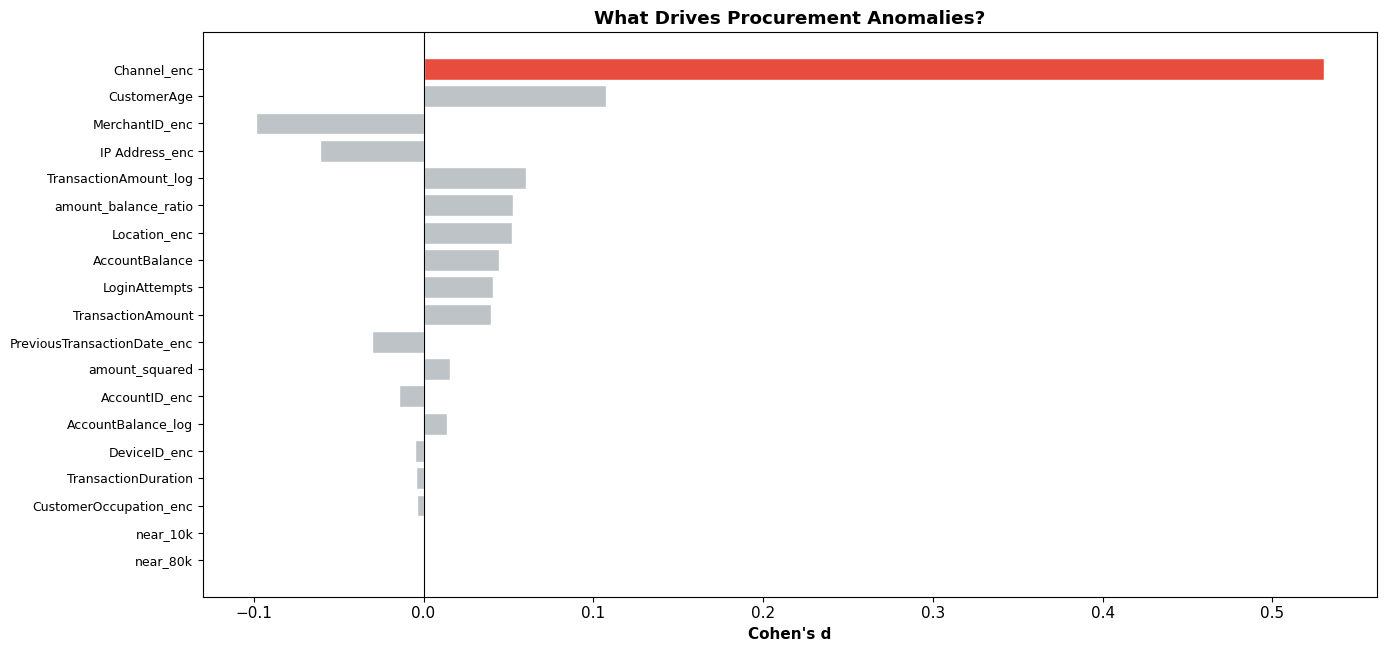

Top anomaly indicators:
  Channel_enc                         d=+0.530
  CustomerAge                         d=+0.108
  MerchantID_enc                      d=-0.098
  IP Address_enc                      d=-0.061
  TransactionAmount_log               d=+0.060
  amount_balance_ratio                d=+0.053
  Location_enc                        d=+0.052
  AccountBalance                      d=+0.044


In [10]:
# Cohen's d
cohens_d = {}
for i, col in enumerate(feature_cols):
    ok = X[y==0,i]; fr = X[y==1,i]
    ps = np.sqrt((ok.std()**2 + fr.std()**2)/2)
    cohens_d[col] = (fr.mean() - ok.mean()) / ps if ps > 0 else 0

sorted_effects = sorted(cohens_d.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(14, max(6, min(20,len(sorted_effects))*0.35)))
feats = [x[0] for x in sorted_effects[:20]]; vals = [x[1] for x in sorted_effects[:20]]
colors = [COLOR_FRAUD if abs(d)>0.3 else COLOR_LEGIT if abs(d)>0.15 else '#bdc3c7' for d in vals]
ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=9)
ax.set_xlabel("Cohen's d", fontweight='bold')
ax.set_title("What Drives Procurement Anomalies?", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

print("Top anomaly indicators:")
for f, d in sorted_effects[:8]:
    print(f"  {f:35s} d={d:+.3f}")

---
## 5. Model Training & Comparison

In [11]:
nf = y.sum(); nl = (1-y).sum(); sr = nl/nf
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=12),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=sr, random_state=42, eval_metric='logloss', max_depth=6, learning_rate=0.1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=-1, learning_rate=0.05, verbose=-1, num_leaves=31, min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0)
}
print(f"Ratio: 1:{sr:.1f} | Samples: {len(X):,} | Features: {X.shape[1]}")

Ratio: 1:3.4 | Samples: 2,512 | Features: 19


In [12]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}; oof_preds = {}; oof_probs = {}

for mn, mt in models.items():
    print(f"\n{'='*60}\n{mn}\n{'='*60}")
    op = np.zeros(len(y), dtype=int); ob = np.zeros(len(y)); t0 = time.time()
    for fold, (tri, vai) in enumerate(skf.split(X, y)):
        m = clone(mt); m.fit(X[tri], y[tri])
        op[vai] = m.predict(X[vai]); ob[vai] = m.predict_proba(X[vai])[:,1]
        print(f"  Fold {fold+1}: F1={f1_score(y[vai],op[vai]):.4f} | PR-AUC={average_precision_score(y[vai],ob[vai]):.4f}")
    elapsed = time.time() - t0
    results[mn] = {'accuracy': accuracy_score(y,op), 'precision': precision_score(y,op,zero_division=0),
                    'recall': recall_score(y,op,zero_division=0), 'f1': f1_score(y,op,zero_division=0),
                    'roc_auc': roc_auc_score(y,ob), 'pr_auc': average_precision_score(y,ob),
                    'brier': brier_score_loss(y,ob), 'time': elapsed}
    oof_preds[mn] = op; oof_probs[mn] = ob
    r = results[mn]
    print(f"  OOF: F1={r['f1']:.4f} | PR-AUC={r['pr_auc']:.4f} | ROC-AUC={r['roc_auc']:.4f}")


Logistic Regression
  Fold 1: F1=0.3993 | PR-AUC=0.3169
  Fold 2: F1=0.3856 | PR-AUC=0.2901
  Fold 3: F1=0.3936 | PR-AUC=0.2893
  OOF: F1=0.3928 | PR-AUC=0.2958 | ROC-AUC=0.6337

Random Forest
  Fold 1: F1=0.2353 | PR-AUC=0.3061
  Fold 2: F1=0.1412 | PR-AUC=0.2833
  Fold 3: F1=0.2101 | PR-AUC=0.3037
  OOF: F1=0.1968 | PR-AUC=0.2946 | ROC-AUC=0.6274

XGBoost
  Fold 1: F1=0.2894 | PR-AUC=0.2901
  Fold 2: F1=0.2581 | PR-AUC=0.2618
  Fold 3: F1=0.2946 | PR-AUC=0.2940
  OOF: F1=0.2810 | PR-AUC=0.2793 | ROC-AUC=0.6002

LightGBM
  Fold 1: F1=0.3378 | PR-AUC=0.3017
  Fold 2: F1=0.3224 | PR-AUC=0.2868
  Fold 3: F1=0.3409 | PR-AUC=0.3167
  OOF: F1=0.3338 | PR-AUC=0.2979 | ROC-AUC=0.6181


In [13]:
print("\n" + "="*95 + "\nMODEL COMPARISON\n" + "="*95)
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'ROC':>7} {'PR-AUC':>7} {'Brier':>7}")
print("-"*95)
for n, r in results.items():
    print(f"{n:<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f} {r['pr_auc']:>7.4f} {r['brier']:>7.4f}")
best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])
print(f"\nBest: {best_model[0]} (PR-AUC={best_model[1]['pr_auc']:.4f})")


MODEL COMPARISON
Model                      Acc    Prec  Recall      F1     ROC  PR-AUC   Brier
-----------------------------------------------------------------------------------------------
Logistic Regression     0.5987  0.2985  0.5739  0.3928  0.6337  0.2958  0.2361
Random Forest           0.7432  0.3362  0.1391  0.1968  0.6274  0.2946  0.1797
XGBoost                 0.6720  0.2785  0.2835  0.2810  0.6002  0.2793  0.2075
LightGBM                0.6521  0.2944  0.3856  0.3338  0.6181  0.2979  0.2048

Best: LightGBM (PR-AUC=0.2979)


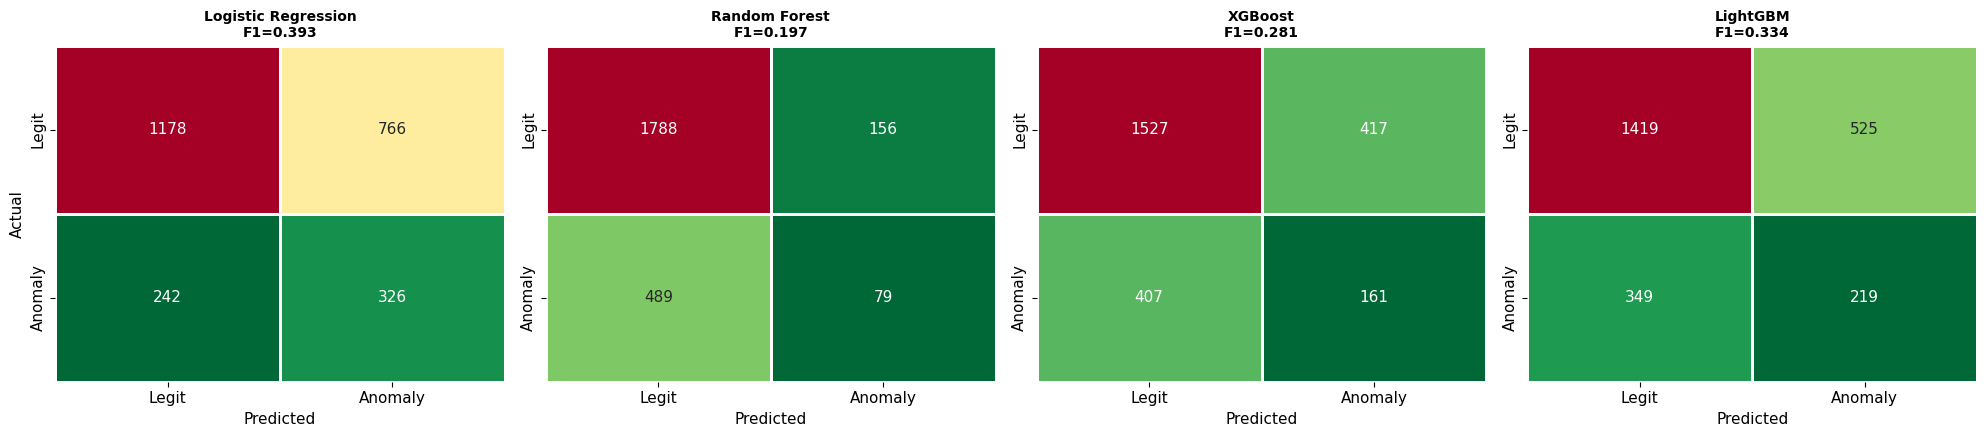

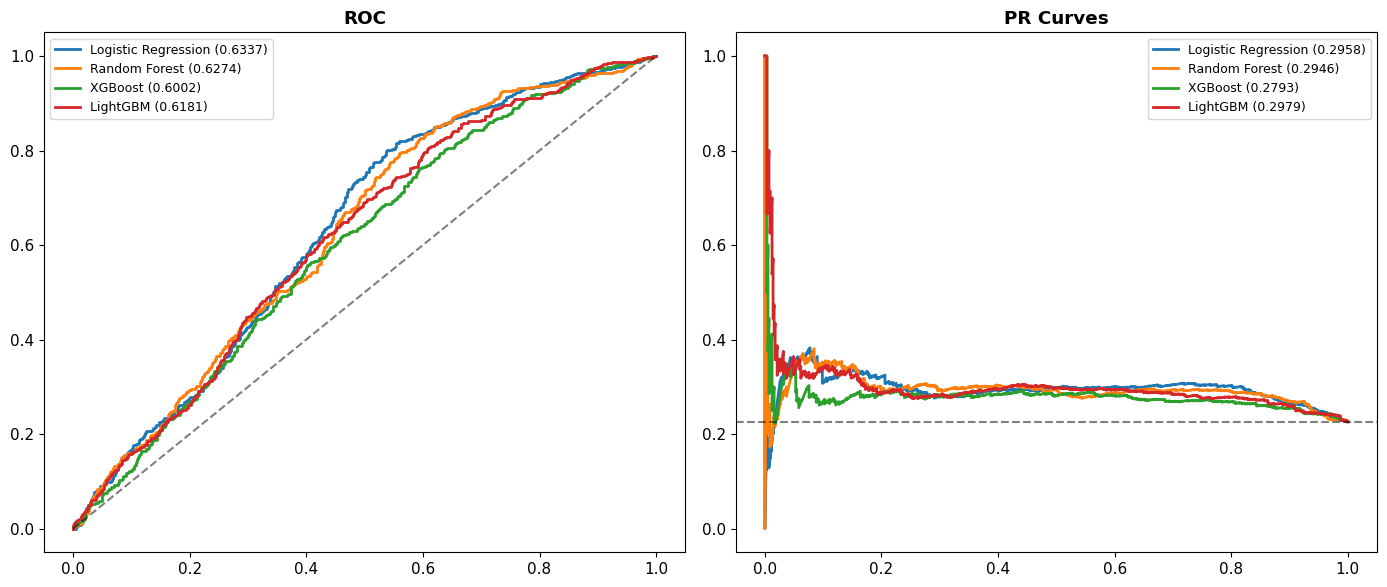

In [14]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, (n, pred) in enumerate(oof_preds.items()):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
                xticklabels=['Legit','Anomaly'], yticklabels=['Legit','Anomaly'], cbar=False, linewidths=1)
    axes[idx].set_title(f'{n}\nF1={results[n]["f1"]:.3f}', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Actual' if idx==0 else ''); axes[idx].set_xlabel('Predicted')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for n, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, prob); axes[0].plot(fpr, tpr, label=f"{n} ({results[n]['roc_auc']:.4f})", linewidth=2)
    prec, rec, _ = precision_recall_curve(y, prob); axes[1].plot(rec, prec, label=f"{n} ({results[n]['pr_auc']:.4f})", linewidth=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5); axes[0].set_title('ROC', fontweight='bold'); axes[0].legend(fontsize=9)
axes[1].axhline(y=y.mean(),color='k',linestyle='--',alpha=0.5); axes[1].set_title('PR Curves', fontweight='bold'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

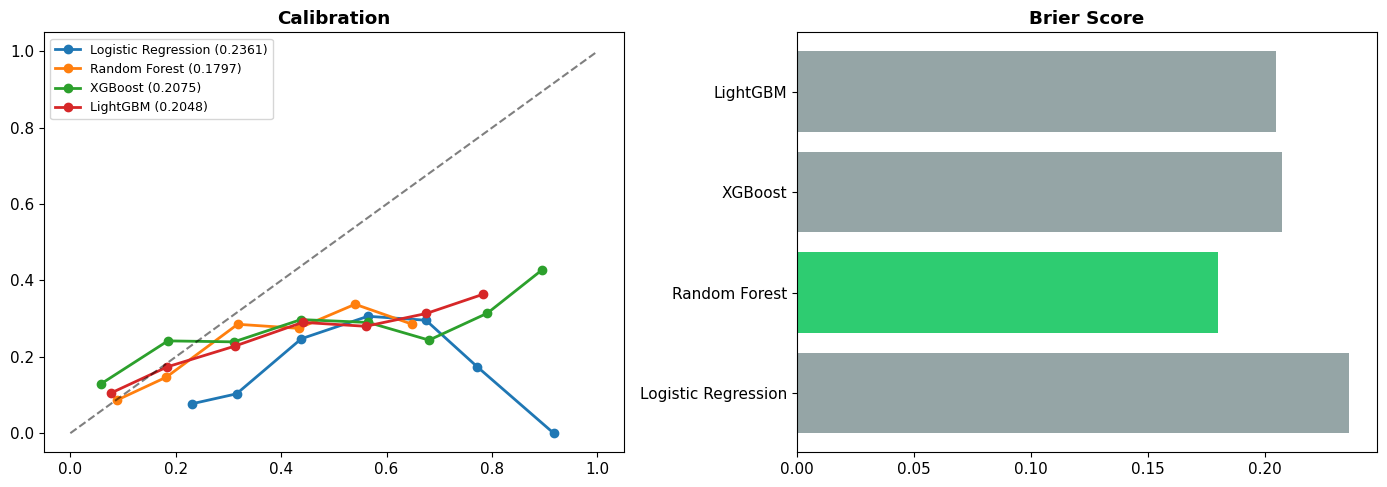

In [15]:
# Calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n, prob in oof_probs.items():
    pt, pp = calibration_curve(y, prob, n_bins=8, strategy='uniform')
    axes[0].plot(pp, pt, marker='o', label=f"{n} ({results[n]['brier']:.4f})", linewidth=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5); axes[0].set_title('Calibration', fontweight='bold'); axes[0].legend(fontsize=9)
brier = [results[n]['brier'] for n in results]
axes[1].barh(list(results.keys()), brier, color=[COLOR_LEGIT if b==min(brier) else '#95a5a6' for b in brier])
axes[1].set_title('Brier Score', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Threshold Tuning & Cost-Sensitive Analysis

Government procurement anomaly detection operates in a **high-scrutiny, audit-driven** environment:

| Risk Tier | Action | CPR Context |
|-----------|--------|-------------|
| **Low** (< 0.2) | Routine processing, no additional review | Below $10k threshold |
| **Medium** (0.2–0.5) | Automated compliance check | $10k–$80k, delegate approval |
| **High** (0.5–0.8) | Manual review by procurement officer | >$80k, mandatory AusTender |
| **Critical** (> 0.8) | Fraud investigation referral | Suspected fraud, ANAO/AFP |

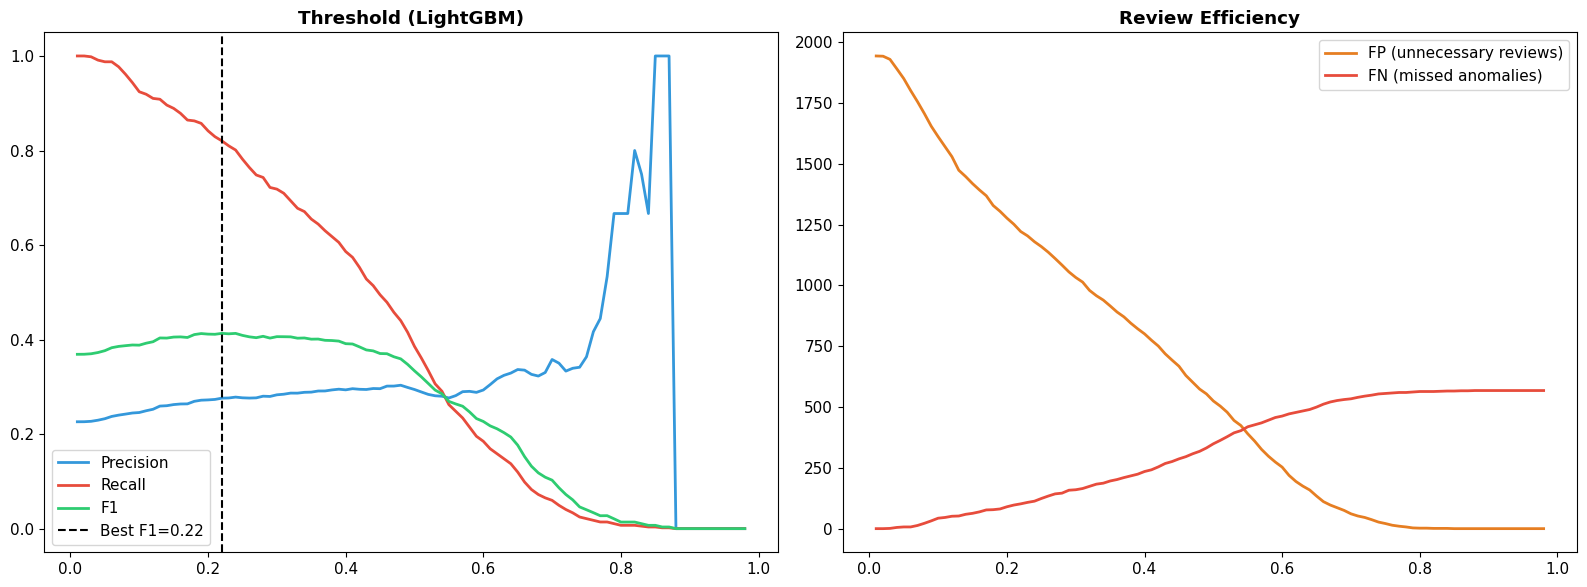

Optimal F1 threshold: 0.22


In [16]:
best_name = best_model[0]; best_prob = oof_probs[best_name]
thr_results = []
for t in np.arange(0.01, 0.99, 0.01):
    pt = (best_prob >= t).astype(int)
    tp=((pt==1)&(y==1)).sum(); fp=((pt==1)&(y==0)).sum(); fn=((pt==0)&(y==1)).sum()
    p=tp/(tp+fp) if (tp+fp)>0 else 0; r=tp/(tp+fn) if (tp+fn)>0 else 0
    f=2*p*r/(p+r) if (p+r)>0 else 0
    thr_results.append({'threshold':t,'precision':p,'recall':r,'f1':f,'tp':tp,'fp':fp,'fn':fn})
thr_df = pd.DataFrame(thr_results)
best_f1_idx = thr_df['f1'].idxmax(); best_f1_thresh = thr_df.loc[best_f1_idx, 'threshold']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(thr_df['threshold'], thr_df['precision'], color='#3498db', label='Precision', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['recall'], color=COLOR_FRAUD, label='Recall', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['f1'], color=COLOR_LEGIT, label='F1', linewidth=2)
axes[0].axvline(x=best_f1_thresh, color='black', linestyle='--', label=f'Best F1={best_f1_thresh:.2f}')
axes[0].set_title(f'Threshold ({best_name})', fontweight='bold'); axes[0].legend()
axes[1].plot(thr_df['threshold'], thr_df['fp'], color='#e67e22', label='FP (unnecessary reviews)', linewidth=2)
axes[1].plot(thr_df['threshold'], thr_df['fn'], color=COLOR_FRAUD, label='FN (missed anomalies)', linewidth=2)
axes[1].set_title('Review Efficiency', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Optimal F1 threshold: {best_f1_thresh:.2f}")

In [17]:
COST_FN = 75000   # Missed fraud: financial loss + reputational damage + ANAO finding
COST_FP = 2000    # Unnecessary review: procurement officer time
COST_TP = 500     # Effective detection: early intervention

scenarios = {
    'Proactive integrity (low thresh)': 0.15,
    'Balanced (Best F1)': best_f1_thresh,
    'Standard compliance': 0.50,
    'Investigation referral only': 0.80,
}
print("=" * 90)
print("PROCUREMENT ANOMALY DETECTION SCENARIOS")
print("=" * 90)
print(f"\n{'Scenario':<40} {'Thresh':>6} {'Recall':>7} {'Prec':>7} {'FP':>6} {'FN':>5} {'Cost':>10}")
print("-" * 90)
for name, thresh in scenarios.items():
    row = thr_df.iloc[(thr_df['threshold']-thresh).abs().argsort()[:1]].iloc[0]
    total = row['fn']*COST_FN + row['fp']*COST_FP + row['tp']*COST_TP
    print(f"{name:<40} {thresh:>6.2f} {row['recall']:>7.4f} {row['precision']:>7.4f} "
          f"{int(row['fp']):>6,} {int(row['fn']):>5,} ${total:>8,.0f}")
print(f"\nANAO audit findings carry significant reputational cost beyond financial loss.")
print(f"The proactive integrity threshold catches more anomalies at modest review cost.")

PROCUREMENT ANOMALY DETECTION SCENARIOS

Scenario                                 Thresh  Recall    Prec     FP    FN       Cost
------------------------------------------------------------------------------------------
Proactive integrity (low thresh)           0.15  0.8891  0.2625  1,419    63 $7,815,500
Balanced (Best F1)                         0.22  0.8204  0.2761  1,222   102 $10,327,000
Standard compliance                        0.50  0.3856  0.2944    525   349 $27,334,500
Investigation referral only                0.80  0.0070  0.6667      2   564 $42,306,000

ANAO audit findings carry significant reputational cost beyond financial loss.
The proactive integrity threshold catches more anomalies at modest review cost.


---
## 7. Model Interpretability

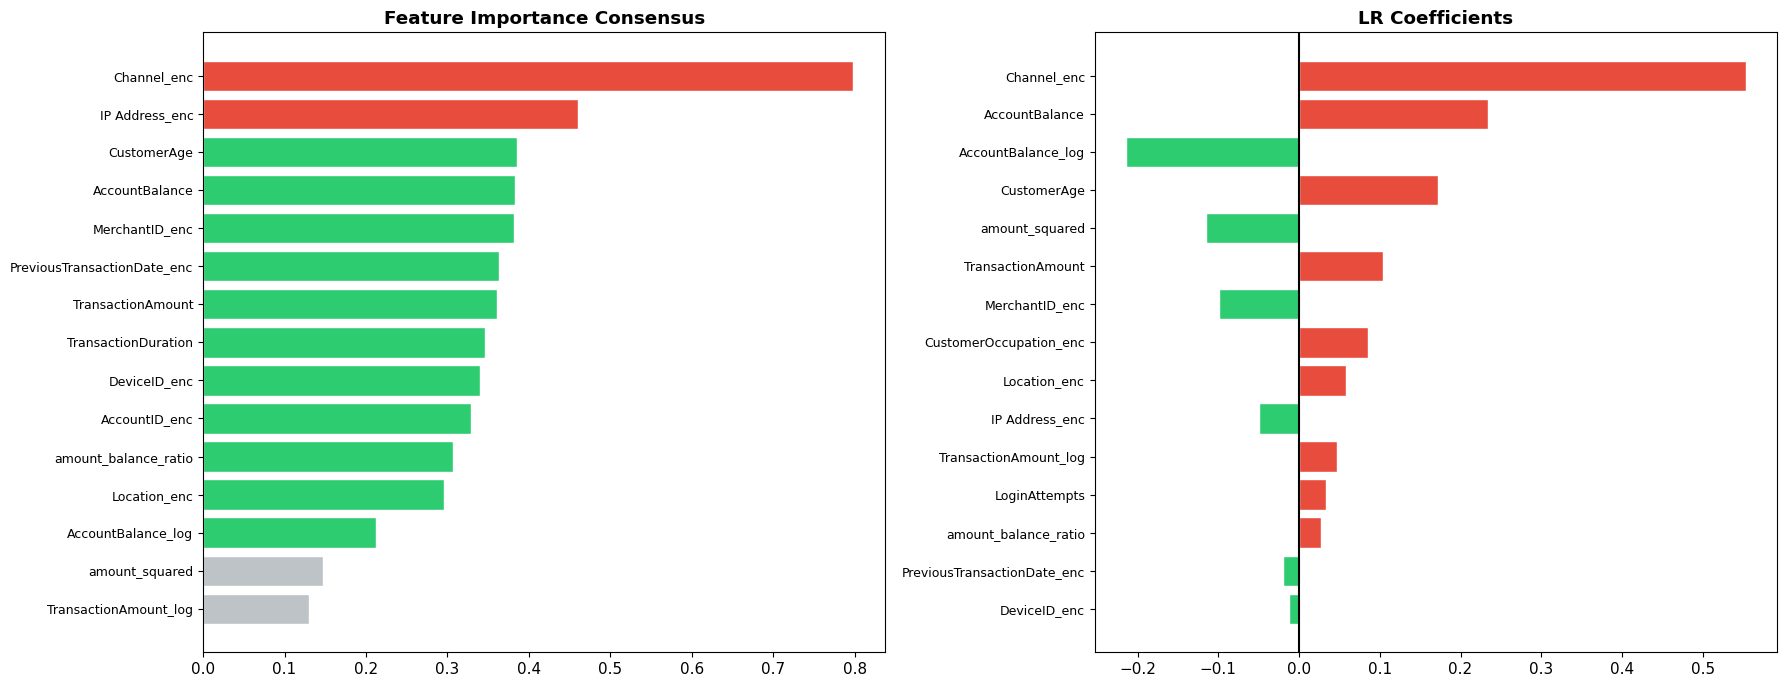

Top 5 anomaly indicators:
  [1] Channel_enc (0.798)
  [2] IP Address_enc (0.461)
  [3] CustomerAge (0.386)
  [4] AccountBalance (0.384)
  [5] MerchantID_enc (0.381)


In [18]:
importances = {}
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42); lr.fit(X,y); importances['LR'] = np.abs(lr.coef_[0])
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=12); rf.fit(X,y); importances['RF'] = rf.feature_importances_
xg = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=sr, random_state=42, eval_metric='logloss', max_depth=6, verbosity=0); xg.fit(X,y); importances['XGB'] = xg.feature_importances_
lg = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=-1, learning_rate=0.05, verbose=-1, num_leaves=31, min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0); lg.fit(X,y); importances['LGBM'] = lg.feature_importances_

ni = {n: imp/imp.max() if imp.max()>0 else imp for n, imp in importances.items()}
ai = np.mean([ni[m] for m in ni], axis=0)
si = np.argsort(ai)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
tn = [feature_cols[i] for i in si]; tv = ai[si]
axes[0].barh(range(len(tn)), tv, color=[COLOR_FRAUD if v>0.4 else COLOR_LEGIT if v>0.2 else '#bdc3c7' for v in tv], edgecolor='white')
axes[0].set_yticks(range(len(tn))); axes[0].set_yticklabels(tn, fontsize=9)
axes[0].set_title('Feature Importance Consensus', fontweight='bold'); axes[0].invert_yaxis()

lrc = lr.coef_[0]; lri = np.argsort(np.abs(lrc))[::-1][:15]
axes[1].barh(range(15), lrc[lri], color=[COLOR_FRAUD if c>0 else COLOR_LEGIT for c in lrc[lri]], edgecolor='white')
axes[1].set_yticks(range(15)); axes[1].set_yticklabels([feature_cols[i] for i in lri], fontsize=9)
axes[1].set_title('LR Coefficients', fontweight='bold'); axes[1].axvline(x=0, color='black'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

print("Top 5 anomaly indicators:")
for i in range(min(5,len(tn))):
    print(f"  [{i+1}] {tn[i]} ({tv[i]:.3f})")

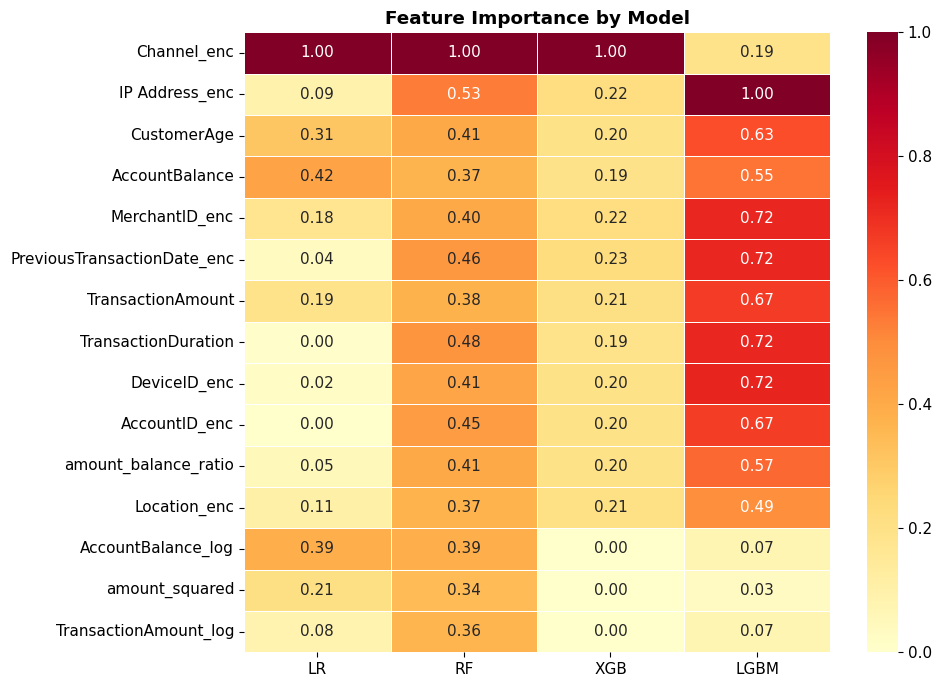

In [19]:
# Heatmap
top_n = min(15, len(feature_cols)); ti = np.argsort(ai)[::-1][:top_n]
hm = pd.DataFrame({n: [ni[n][i] for i in ti] for n in ni}, index=[feature_cols[i] for i in ti])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Feature Importance by Model', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Production Deployment Considerations

### Government Procurement Anomaly Detection Architecture

```
Payment/Invoice Data (SAP, TechOne, Oracle Financials)
    │ + AusTender contract data
    │ + ABR (Australian Business Register) vendor data
    │ + ATO data matching (vendor TFN/ABN validation)
    ▼
Batch Risk Scoring Engine (nightly)
    │
    ├── LOW (< 0.2) ──► Auto-approve, routine processing
    ├── MEDIUM (0.2 - 0.5) ──► Automated compliance check
    │       └── CPR threshold validation, delegate authority check
    ├── HIGH (0.5 - 0.8) ──► Procurement officer review
    │       ├── Value-for-money assessment
    │       ├── Conflict of interest check
    │       └── AusTender publication compliance
    └── CRITICAL (> 0.8) ──► Fraud investigation
            ├── Commonwealth Fraud Prevention Centre referral
            ├── AFP referral (if > $100k or criminal indicators)
            └── ANAO notification
    │
    ▼
Audit Trail (PGPA Act s.101 record-keeping requirements)
```

### Regulatory Framework

| Framework | Authority | Relevance |
|-----------|-----------|-----------|
| **Commonwealth Procurement Rules** | Finance | Mandatory procurement procedures |
| **PGPA Act 2013** | Finance | Proper use of public resources, fraud control |
| **Criminal Code Act 1995** | AGD | Financial fraud offences (s.134, s.135) |
| **Public Interest Disclosure Act 2013** | AGD | Whistleblower protections |
| **AusTender** | Finance | Mandatory reporting of contracts >$10k |
| **ANAO Auditing Standards** | ANAO | Performance audit framework |

### Key Considerations

**Rule-Based Layer First:** The ML model augments, not replaces, the CPR rules engine. Hard rules (delegate authority, threshold checks, mandatory AusTender publication) are non-negotiable and don't need ML.

**Vendor Risk Profiling:** In production, vendor-level features (ABN age, number of government contracts, payment history, related-party indicators) would significantly improve model performance.

**Cross-Entity Analytics:** Procurement fraud often spans agencies — a vendor submitting similar invoices to multiple departments. Whole-of-government data sharing (via the Commonwealth Fraud Prevention Centre) enables cross-entity anomaly detection.

**Audit Integration:** Every model score and human decision must be logged per PGPA Act s.101. The ANAO must be able to reconstruct the decision trail for any flagged transaction.

---
## 9. Key Takeaways

In [20]:
print("=" * 70)
print("PROCUREMENT ANOMALY DETECTION — KEY RESULTS")
print("=" * 70)
print(f"\n1. DATASET: {len(df):,} transactions, {fraud_pct:.2f}% anomaly rate")
print(f"\n2. BEST MODEL: {best_model[0]}")
print(f"   PR-AUC:  {best_model[1]['pr_auc']:.4f}")
print(f"   ROC-AUC: {best_model[1]['roc_auc']:.4f}")
print(f"   F1:      {best_model[1]['f1']:.4f}")
print(f"\n3. MODEL COMPARISON (PR-AUC):")
for n in sorted(results, key=lambda x: results[x]['pr_auc'], reverse=True):
    m = " ◄ BEST" if n == best_model[0] else ""
    print(f"   {n:<22} {results[n]['pr_auc']:.4f}{m}")
print(f"\n4. TOP ANOMALY INDICATORS:")
for i in range(min(5,len(tn))):
    print(f"   [{i+1}] {tn[i]} ({tv[i]:.3f})")
print(f"\n5. PRODUCTION LESSONS:")
print(f"   • Rule-based CPR checks first, ML augments for subtle anomalies")
print(f"   • Cross-entity analytics essential — fraud spans agencies")
print(f"   • Vendor risk profiling (ABN, payment history) improves detection")
print(f"   • PGPA Act s.101 requires full audit trail")
print(f"   • ANAO audit findings carry reputational cost beyond financial")
print(f"   • Commonwealth Fraud Prevention Centre coordinates whole-of-government response")
print(f"   • AFP referral for amounts >$100k or criminal indicators")
print(f"\n{'='*70}")
print(f"Notebook by Dean | Lead Data & AI Engineer | Fujitsu Australia")
print(f"Part of the Production ML Portfolio Series:")
print(f"  [1] Network Intrusion Detection (Cybersecurity)")
print(f"  [2] Cardiovascular Disease Prediction (Healthcare)")
print(f"  [3] Credit Card Fraud Detection (Financial Crime)")
print(f"  [4] Predictive Maintenance (Defence & Infrastructure)")
print(f"  [5] Visa Risk Scoring (Immigration & Border Security)")
print(f"  [6] Benefits Fraud Detection (Welfare Compliance)")
print(f"  [7] Tax Compliance Risk Scoring (Revenue Administration)")
print(f"  [8] Digital Service Engagement (Government Platforms)")
print(f"  [9] Procurement Anomaly Detection (Supply Chain Integrity) ← This notebook")
print(f"{'='*70}")

PROCUREMENT ANOMALY DETECTION — KEY RESULTS

1. DATASET: 2,512 transactions, 22.61% anomaly rate

2. BEST MODEL: LightGBM
   PR-AUC:  0.2979
   ROC-AUC: 0.6181
   F1:      0.3338

3. MODEL COMPARISON (PR-AUC):
   LightGBM               0.2979 ◄ BEST
   Logistic Regression    0.2958
   Random Forest          0.2946
   XGBoost                0.2793

4. TOP ANOMALY INDICATORS:
   [1] Channel_enc (0.798)
   [2] IP Address_enc (0.461)
   [3] CustomerAge (0.386)
   [4] AccountBalance (0.384)
   [5] MerchantID_enc (0.381)

5. PRODUCTION LESSONS:
   • Rule-based CPR checks first, ML augments for subtle anomalies
   • Cross-entity analytics essential — fraud spans agencies
   • Vendor risk profiling (ABN, payment history) improves detection
   • PGPA Act s.101 requires full audit trail
   • ANAO audit findings carry reputational cost beyond financial
   • Commonwealth Fraud Prevention Centre coordinates whole-of-government response
   • AFP referral for amounts >$100k or criminal indicators

No